In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
import wandb
import copy
import timm
import random

In [ ]:
# CONFIGURATION
# ============================================================================
CONFIG = {
    # Paths
    'DATASET_PATH': '/content/drive/MyDrive/Dataset/castor_v2_224x224',

    # Training
    'BATCH_SIZE': 16,
    'NUM_EPOCHS': 50,
    'LEARNING_RATE': 1e-4,
    'WEIGHT_DECAY': 0.01,
    'DROPOUT': 0.3,

    # K-Fold
    'K_FOLDS': 5,
    'RANDOM_STATE': 42,

    # Model
    'NUM_CLASSES': 3,
    'IMG_SIZE': 224,

    # W&B
    'PROJECT_NAME': 'CoAtNet_imagenet',
    'usewandb':False
}

RANDOM_STATE = CONFIG['RANDOM_STATE']

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
random.seed(hash("setting random seeds") % 2**32 - 1)
np.random.seed(hash("improves reproducibility") % 2**32 - 1)
torch.manual_seed(hash("by removing stochasticity") % 2**32 - 1)
torch.cuda.manual_seed_all(hash("so runs are repeatable") % 2**32 - 1)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# ============================================================================
# DATASET
# ============================================================================
class ImageDataset(Dataset):
    """Dataset for loading images from folder structure"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dataset():
    """Load dataset from folder structure"""
    dataset_path = CONFIG['DATASET_PATH']

    image_paths = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    print(f"Found classes: {class_names}")

    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(img_path)
                labels.append(class_to_idx[class_name])

    print(f"Total images: {len(image_paths)}")
    print(f"Class distribution: {np.bincount(labels)}")

    # Create transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    # Create dataset
    dataset = ImageDataset(np.array(image_paths), np.array(labels), transform)
    return dataset, class_names

In [ ]:
# ============================================================================
# MODEL
# ============================================================================

class CoAtNetTiny(nn.Module):
    """CoAtNet-0 (Tiny) model with custom head"""
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()

        # Load CoAtNet-0 backbone (tiniest version)
        # Using coatnet_0_rw_224 which is the smallest CoAtNet variant
        self.backbone = timm.create_model(
            'coatnet_0_rw_224',
            pretrained=True,
            num_classes=0  # Remove classification head
        )

        # Get feature dimension
        self.feature_dim = self.backbone.num_features

        # Custom classification head
        self.head = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes)
        )

        self._init_head()

    def _init_head(self):
        """Initialize classification head"""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def get_num_params(self, trainable_only=False):
        if trainable_only:
            return sum(p.numel() for p in self.parameters() if p.requires_grad)
        return sum(p.numel() for p in self.parameters())


def build_coatnet_model(num_classes, dropout=0.3):
    """Build CoAtNet model"""
    model = CoAtNetTiny(num_classes=num_classes, dropout=dropout)
    print(f"✓ CoAtNet-0 model created")
    print(f"Feature dimension: {model.feature_dim}")
    return model

In [ ]:
# ============================================================================
# TRAINING UTILITIES
# ============================================================================

def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """Plot confusion matrix"""
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        cm_display = np.round(cm * 100, 1)
        fmt = ".1f"
    else:
        cm_display = cm
        fmt = "d"

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count' if not normalize else 'Percentage (%)'})

    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    ax.set_title("Confusion Matrix")

    plt.tight_layout()
    return fig

In [ ]:
# ============================================================================
# TRAIN FOLD
# ============================================================================

def train_fold(fold_idx, train_loader, val_loader, group_name, class_names):
    """Trains a single fold with early stopping on validation accuracy."""
    if CONFIG.get("usewandb"):
        wandb.init(
            project=CONFIG["PROJECT_NAME"],
            group=group_name,
            name=f"fold-{fold_idx}",
            job_type="train",
            config=CONFIG,
            reinit=True
        )

    model = build_coatnet_model(
        num_classes=CONFIG['NUM_CLASSES'],
        dropout=CONFIG['DROPOUT']
    ).to(device)

    print(f"\nTotal parameters: {model.get_num_params():,}")
    print(f"Trainable parameters: {model.get_num_params(trainable_only=True):,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CONFIG["LEARNING_RATE"],
        weight_decay=CONFIG["WEIGHT_DECAY"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.3
    )

    best_val_acc = -np.inf
    best_weights = None
    patience = 8
    patience_counter = 0
    best_epoch = -1

    for epoch in range(CONFIG["NUM_EPOCHS"]):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['NUM_EPOCHS']}")
        for batch_X, batch_y in progress:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            _, predicted_train = torch.max(outputs.data, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted_train == batch_y).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = correct_train / total_train

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)

                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs.data, 1)

                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

                all_labels.append(batch_y.cpu().numpy())
                all_preds.append(predicted.cpu().numpy())
                all_probs.append(probs.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total

        all_labels = np.concatenate(all_labels)
        all_preds = np.concatenate(all_preds)
        all_probs = np.concatenate(all_probs)

        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

        try:
            roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
        except:
            roc_auc = float("nan")

        cm_fig = plot_confusion_matrix(all_labels, all_preds, class_names, normalize=False)

        # Early Stopping based on val_accuracy
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_epoch = epoch + 1
            patience_counter = 0
            best_weights = copy.deepcopy(model.state_dict())
            print(f"   ✓️ New best model (epoch {best_epoch}, val_acc={best_val_acc:.4f})")
        else:
            patience_counter += 1
            print(f"   Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("⛔️ Early stopping triggered")
            break

        scheduler.step(val_accuracy)

        if CONFIG.get("usewandb"):
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": avg_train_loss,
                "train_accuracy": train_accuracy,
                "val_loss": avg_val_loss,
                "val_accuracy": val_accuracy,
                "val_precision": precision,
                "val_recall": recall,
                "val_roc_auc": roc_auc,
                "current_lr": optimizer.param_groups[0]["lr"],
                "confusion_matrix": wandb.Image(cm_fig),
                "fold": fold_idx
            })

        plt.close(cm_fig)

        print(f"Fold {fold_idx} | Epoch {epoch+1} | "
              f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | "
              f"Prec: {precision:.4f} | Rec: {recall:.4f} | ROC-AUC: {roc_auc:.4f}")

    # Final Eval
    if best_weights is None:
        raise RuntimeError("No best_weights found")

    model.load_state_dict(best_weights)
    print(f"✓️ Loaded best model (epoch {best_epoch})")

    # Final validation with best weights
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)
            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)

            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

            all_labels.append(batch_y.cpu().numpy())
            all_preds.append(predicted.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    final_avg_val_loss = val_loss / len(val_loader)
    final_val_accuracy = correct / total

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    all_probs = np.concatenate(all_probs)

    final_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    final_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    try:
        final_roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except:
        final_roc_auc = float("nan")

    final_cm_fig = plot_confusion_matrix(all_labels, all_preds, class_names, normalize=False)

    save_path = f"{group_name}_best_fold_{fold_idx}.pt"
    torch.save(best_weights, save_path)
    print(f"✓️ Saved checkpoint to {save_path}")

    if CONFIG.get("usewandb"):
        artifact = wandb.Artifact(
            name=f"{group_name}_model_fold_{fold_idx}",
            type="model",
            description=f"Best checkpoint for fold {fold_idx} (epoch={best_epoch})"
        )
        artifact.add_file(save_path)
        wandb.log_artifact(artifact)

        metrics_table = wandb.Table(columns=[
            "fold", "best_epoch", "final_val_accuracy",
            "final_precision", "final_recall", "final_roc_auc"
        ])
        metrics_table.add_data(
            fold_idx, best_epoch, final_val_accuracy,
            final_precision, final_recall, final_roc_auc
        )

        wandb.log({
            "best_model_metrics": metrics_table,
            "best_model_confusion_matrix": wandb.Image(final_cm_fig)
        })
        wandb.finish()

    plt.close(final_cm_fig)

    return {
        'fold': fold_idx,
        'best_epoch': best_epoch,
        'val_accuracy': final_val_accuracy,
        'precision': final_precision,
        'recall': final_recall,
        'roc_auc': final_roc_auc
    }


✓ Random seed set to 42
Using device: cuda
Starting K-Fold Experiment: CoAtNet-KFold-v1
Found classes: ['Fresh Leafs', 'Semilooper', 'Spodoptera']
Total images: 991
Class distribution: [478 320 193]
Class names: ['Fresh Leafs', 'Semilooper', 'Spodoptera']

Starting Fold 1/5


✓ CoAtNet-0 model created
Feature dimension: 768

Total parameters: 27,063,365
Trainable parameters: 27,063,365


Epoch 1/50: 100%|██████████| 50/50 [00:13<00:00,  3.78it/s]


   ✓️ New best model (epoch 1, val_loss=0.1711)
Fold 1 | Epoch 1 | Train Acc: 0.8523 | Val Acc: 0.9698 | Prec: 0.9680 | Rec: 0.9563 | ROC-AUC: 0.9909


Epoch 2/50: 100%|██████████| 50/50 [00:12<00:00,  4.05it/s]


...

Epoch 14/50: 100%|██████████| 50/50 [00:13<00:00,  3.77it/s]


   Patience: 8/8
⛔️ Early stopping triggered
✓️ Loaded best model (epoch 6)
✓️ Saved checkpoint to CoAtNet-KFold-v1_best_fold_5.pt
✓️ Uploaded artifact to W&B


/usr/local/lib/python3.12/dist-packages/plotly/matplotlylib/renderer.py:571: UserWarning:

Dang! That path collection is out of this world. I totally don't know what to do with it yet! Plotly can only import path collections linked to 'data' coordinates



current_lr,█████████▁▁▁▁
epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
fold,▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▇▇▇█████████
train_loss,█▃▃▂▂▂▁▂▂▁▁▁▁
val_accuracy,▁▃▅▇▆▇▆▇▆▇▇█▇
val_loss,█▅▅▄▅▁▅▂▃▃▂▂▂
val_precision,▂▁▃▇▅▆▅▆▄▆▇█▆
val_recall,▁▅▆▇▆█▇▇▇▇▇██
val_roc_auc,▁▆▅▇▇▇▇▆█▇███
current_lr,3e-05



K-FOLD CROSS VALIDATION SUMMARY

Accuracy:  0.9697 ± 0.0237
Precision: 0.9644 ± 0.0286
Recall:    0.9595 ± 0.0270
ROC-AUC:   0.9965 ± 0.0041

Fold 1: Acc=0.9698, F1=0.9630

Fold 2: Acc=0.9899, F1=0.9853

Fold 3: Acc=0.9798, F1=0.9728

Fold 4: Acc=0.9242, F1=0.9093

Fold 5: Acc=0.9848, F1=0.9791


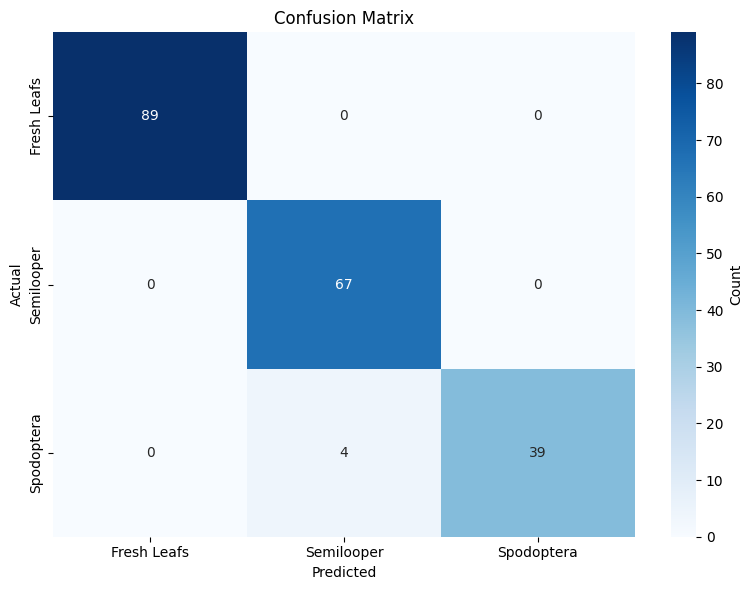

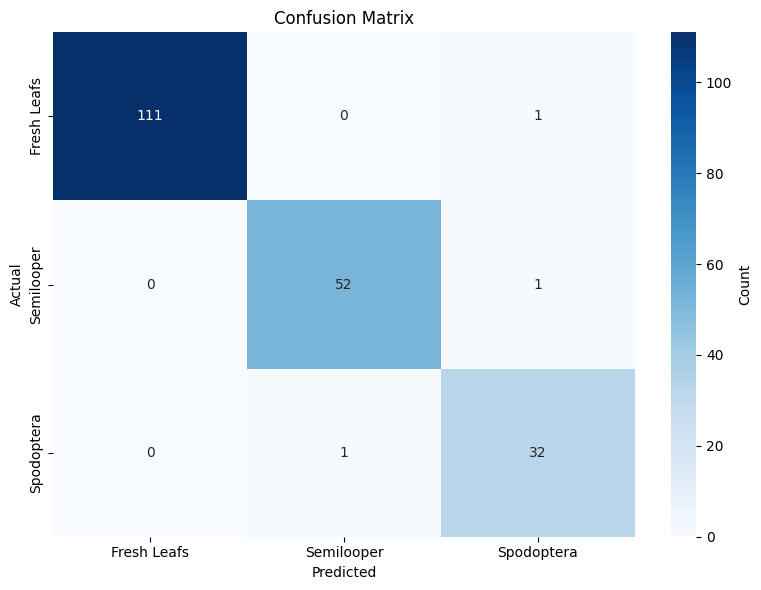

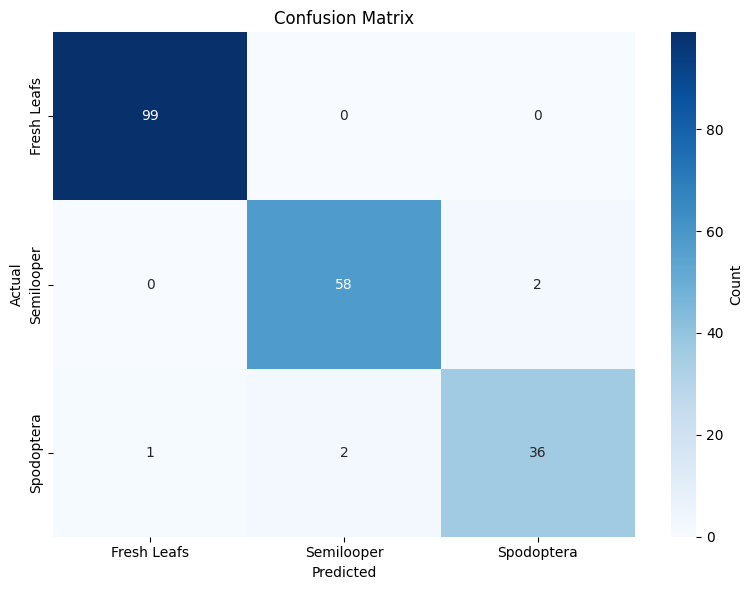

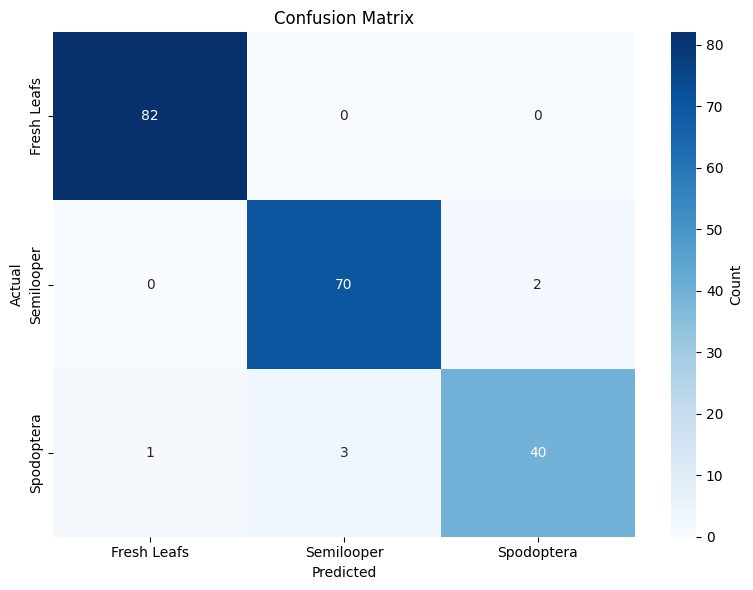

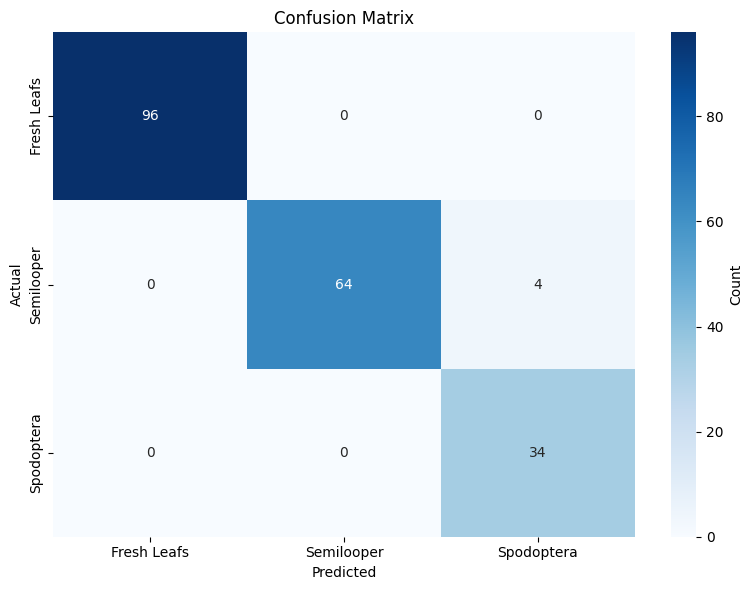

In [ ]:
# ============================================================================
# MAIN K-FOLD LOOP
# ============================================================================

def run_k_fold():
    """Run K-Fold cross-validation"""
    suffix = "v1"
    experiment_group_name = f"CoAtNet-KFold-{suffix}"
    print(f"Starting K-Fold Experiment: {experiment_group_name}")

    # Load dataset
    dataset, class_names = get_dataset()
    print(f"Class names: {class_names}")

    # K-Fold splitter
    kf = KFold(n_splits=CONFIG["K_FOLDS"], shuffle=True, random_state=RANDOM_STATE)

    # Store results
    all_results = []

    # K-Fold loop
    for fold_idx, (train_indices, val_indices) in enumerate(kf.split(np.arange(len(dataset)))):
        print(f"\n{'='*60}")
        print(f"Starting Fold {fold_idx + 1}/{CONFIG['K_FOLDS']}")
        print(f"{'='*60}")

        # Create subsets
        train_subset = Subset(dataset, train_indices)
        val_subset = Subset(dataset, val_indices)

        # Create dataloaders
        train_loader = DataLoader(
            train_subset,
            batch_size=CONFIG["BATCH_SIZE"],
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
        val_loader = DataLoader(
            val_subset,
            batch_size=CONFIG["BATCH_SIZE"],
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # Train fold
        fold_result = train_fold(
            fold_idx + 1,
            train_loader,
            val_loader,
            experiment_group_name,
            class_names
        )
        all_results.append(fold_result)

    # ------------------- SUMMARY -------------------
    print(f"\n{'='*60}")
    print("K-FOLD CROSS VALIDATION SUMMARY")
    print(f"{'='*60}")

    accuracies = [r['val_accuracy'] for r in all_results]
    precisions = [r['precision'] for r in all_results]
    recalls = [r['recall'] for r in all_results]
    roc_aucs = [r['roc_auc'] for r in all_results]

    print(f"\nAccuracy:  {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
    print(f"Recall:    {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
    print(f"ROC-AUC:   {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")

    for i, result in enumerate(all_results):
        print(f"\nFold {result['fold']}: Acc={result['val_accuracy']:.4f}, "
              f"F1={(result['precision'] + result['recall'])/2:.4f}")


# ============================================================================
# RUN
# ============================================================================

if __name__ == '__main__':
    run_k_fold()